In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "591ab4e3a3e575d95d805a92550ef076fd65a824"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/591ab4e3a3e575d95d805a92550ef076fd65a824/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Diffusion Models for Images

Nothing in the previous section depended on the data being two-dimensional.
The forward process, the bound, the noise-prediction loss, and the sampler
apply verbatim to images; what changes is the network, which must map an
image and a step index to an image, and the amount of computation. This
section trains the diffusion model of that section on
Fashion-MNIST with the U-Net of that section, adds a
class label as a condition, and uses the label to demonstrate
classifier-free guidance, the mechanism by which diffusion models are
steered toward a class or a caption, and its predecessor, classifier
guidance, on the same requests and noise draws. It closes with the
developments that
turned this construction into the image generators in current use. The
presentation follows lecture 13 of @Kuleshov.2023 .

In [1]:
%matplotlib inline
from d2l import torch as d2l
import copy
import torch
from torch import nn

## Data, Schedule, and Model

The images are scaled to $[-1, 1]$, as in @ho2020denoising, so that
the data have roughly unit scale, the scale of the standard Gaussian from
which the reverse process starts; the noise levels of the schedule are
calibrated against that scale. The schedule is the one of
@ho2020denoising: $T = 1000$ steps with $\beta_t$ increasing
linearly from $10^{-4}$ to $0.02$.

In [2]:
device = d2l.try_gpu()
fmnist = d2l.FashionMNIST(batch_size=128)
X = (fmnist.train.data.float()[:, None] / 255 * 2 - 1).to(device)
Y = fmnist.train.targets.to(device)
X_test = (fmnist.val.data.float()[:, None] / 255 * 2 - 1).to(device)
Y_test = fmnist.val.targets.to(device)

T = 1000
beta = torch.linspace(1e-4, 0.02, T, device=device)
alpha = 1 - beta
alpha_bar = torch.cumprod(alpha, 0)

The noise predictor is the U-Net `d2l.UNet` of
that section, with the step index $t$ in place of the
noise-level index. To make the model conditional we add a second embedding
to the time embedding: a learned vector per class $c$, the label $y$ of
the equation (`y` in the code). The embedding table
has one extra row, a *null label* $\varnothing$ that carries no class
information, and during training each example's label is replaced by the
null label with probability $0.1$. The network therefore learns two
predictors at once, the conditional
$\boldsymbol{\epsilon}_{\boldsymbol{\theta}}(\mathbf{x}_t, t, c)$ and the
unconditional $\boldsymbol{\epsilon}_{\boldsymbol{\theta}}(\mathbf{x}_t, t, \varnothing)$;
this is the training procedure of classifier-free guidance
[@Ho.Salimans.2022], and "Sampling and Guidance" below explains why
both predictors are wanted.

In [3]:
NULL = 10  # the label index that carries no class information

class ConditionalUNet(nn.Module):
    def __init__(self, num_classes=10, emb_dim=128):
        super().__init__()
        self.unet = d2l.UNet(emb_dim=emb_dim)
        self.embed = nn.Embedding(num_classes + 1, emb_dim)  # + the null label

    def forward(self, x, t, y):
        return self.unet(x, t, cond=self.embed(y))

## Training

The loop is the training procedure of that section with
label dropout added. One further device is standard in diffusion training:
sampling uses an exponential moving average of the weights rather than the
weights themselves, because the parameters at any single step carry
optimization noise that averaging reduces
(that section). @ho2020denoising use
a decay of $0.9999$ over hundreds of thousands of updates; for a run of
$1500$ updates we let the decay rise as $(1 + s) / (10 + s)$ with the step
$s$, capped at $0.999$, so that the average is not dominated by the
initialization; it reaches $0.994$ by the last update, and the average is
dominated by the last few hundred updates. Each update costs a forward and
backward pass through the U-Net on a batch of $128$ images, and the run
takes about ten minutes on a laptop processor.

In [4]:
torch.manual_seed(0)
net = ConditionalUNet().to(device)
ema = copy.deepcopy(net)  # the exponential moving average of the weights
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
for step in range(1500):
    idx = torch.randint(0, len(X), (128,), device=device)
    x0, y = X[idx], Y[idx].clone()
    y[torch.rand(128, device=device) < 0.1] = NULL  # label dropout
    t = torch.randint(0, T, (128,), device=device)
    eps = torch.randn_like(x0)
    a = alpha_bar[t][:, None, None, None]
    loss = ((net(a.sqrt() * x0 + (1 - a).sqrt() * eps, t, y) - eps) ** 2).mean()
    optimizer.zero_grad(), loss.backward(), optimizer.step()
    decay = min(0.999, (1 + step) / (10 + step))
    with torch.no_grad():
        for p_ema, p in zip(ema.parameters(), net.parameters()):
            p_ema.mul_(decay).add_(p, alpha=1 - decay)
    if (step + 1) % 500 == 0:
        print(f'step {step + 1}: loss {loss.item():.3f}')

step 500: loss 0.065


step 1000: loss 0.057


step 1500: loss 0.043


## Sampling and Guidance

The sampler is ancestral sampling from that section, with
one addition that lets a single function serve every classifier-free
experiment below.
Conditioning a score model on a label follows from Bayes' rule, as
the equation showed: the conditional score is the
unconditional score plus the input gradient of $\log p_t(c \mid \mathbf{x})$,
evaluated at the current noise level. *Classifier guidance*
[@Dhariwal.Nichol.2021] supplies that gradient from a classifier trained
on noisy images and scales it by a factor $s > 1$ to strengthen the class
signal. *Classifier-free guidance* [@Ho.Salimans.2022] removes the
classifier by applying Bayes' rule once more: the gradient of
$\log p_t(c \mid \mathbf{x})$ equals the difference between the conditional
and the unconditional score, and a network trained with label dropout
provides both. In the noise-prediction parameterization, where score and
noise differ by a constant factor, the guided prediction is

$$
\tilde{\boldsymbol{\epsilon}}(\mathbf{x}_t, t, c)
= \boldsymbol{\epsilon}_{\boldsymbol{\theta}}(\mathbf{x}_t, t, \varnothing)
+ \gamma\, \big( \boldsymbol{\epsilon}_{\boldsymbol{\theta}}(\mathbf{x}_t, t, c) - \boldsymbol{\epsilon}_{\boldsymbol{\theta}}(\mathbf{x}_t, t, \varnothing) \big),
$$

which the figure draws as an extrapolation. With
$\gamma = 0$ the label is ignored and the sampler is unconditional; with
$\gamma = 1$ it uses the conditional prediction, which is the model's own
estimate of the class-conditional score; with $\gamma > 1$ it moves past the
conditional prediction along the class direction, which sharpens the class
identity of the samples and reduces their diversity.
@Ho.Salimans.2022 write the same rule with a guidance weight $w$ as
$(1 + w)\, \boldsymbol{\epsilon}_{\boldsymbol{\theta}}(\mathbf{x}_t, t, c) - w\, \boldsymbol{\epsilon}_{\boldsymbol{\theta}}(\mathbf{x}_t, t, \varnothing)$,
so $\gamma = 1 + w$.
that section shows that
the equation is the equation applied to the noise
prediction and records the caveat that for $\gamma > 1$ the guided field is
in general no longer the score of any noised data distribution; the
practical value of pushing past $\gamma = 1$ is an empirical finding, and
the experiment below measures it.

![Classifier-free guidance as an extrapolation of noise predictions, drawn as arrows from the current state $\mathbf{x}_t$. The network provides the unconditional prediction (grey) and the conditional one (blue); their difference is the class direction, and the guided prediction (orange) moves along it by a factor $\gamma$, past the conditional prediction when $\gamma > 1$.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-diffusion-guidance.svg)

The function evaluates the conditional and unconditional predictions in one
batched forward pass, combines them with the equation, and
takes the reverse step.

In [5]:
@torch.no_grad()
def sample(net, y, gamma, seed=0):
    """Ancestral sampling with classifier-free guidance of scale gamma."""
    torch.manual_seed(seed)
    n, null = len(y), torch.full_like(y, NULL)
    x = torch.randn(n, 1, 28, 28, device=device)
    for t in reversed(range(T)):
        tt = torch.full((n,), t, device=device)
        eps_c, eps_u = net(torch.cat([x, x]), torch.cat([tt, tt]),
                           torch.cat([y, null])).chunk(2)
        eps = eps_u + gamma * (eps_c - eps_u)
        mean = (x - beta[t] / (1 - alpha_bar[t]).sqrt() * eps) / alpha[t].sqrt()
        x = mean + (beta[t].sqrt() * torch.randn_like(x) if t > 0 else 0)
    return x

def show(imgs, rows, cols):
    imgs = imgs.clamp(-1, 1) / 2 + 0.5
    d2l.show_images(imgs.permute(0, 2, 3, 1).repeat(1, 1, 1, 3), rows, cols,
                    scale=0.8)

### Unconditional Samples

With $\gamma = 0$ the label plays no role. Forty-eight samples, each the
result of a thousand reverse steps from Gaussian noise with the averaged
weights, take one to two minutes.

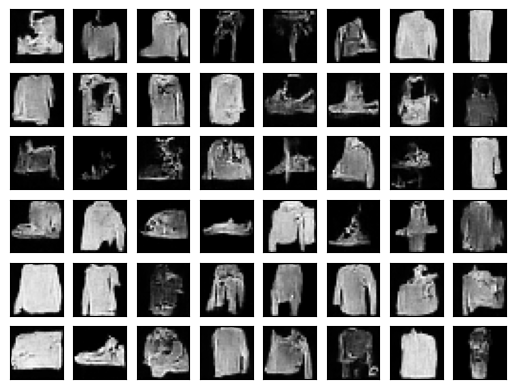

In [6]:
samples = sample(ema, torch.full((48,), NULL, device=device), gamma=0.0)
show(samples, 6, 8)

Many of the samples are recognizable garments and shoes, generated by a
network of about 340 thousand parameters trained for 1500 updates. Many
others are malformed, with uneven outlines, coarse textures, or shapes that
mix several classes, a consequence of that budget. The CIFAR-10 model of
@ho2020denoising has 35.7 million parameters, about a hundred times
as many, and trained for 800 thousand updates.

### Guided Samples

The guidance experiment requests eight samples of every class at three
guidance scales. The field measures the fidelity and diversity of samples
with feature-space statistics such as the FID and precision--recall of
that section, which need a pretrained feature network and thousands
of samples; for $28 \times 28$ images from a ten-minute model, two direct
proxies serve. To measure what guidance does, we train a small
convolutional classifier on the clean training images, which reaches close
to ninety percent test accuracy in seconds, and use it to score the
samples. This classifier only measures the samples; it plays no part in
sampling, unlike the noise-trained classifier of classifier guidance.
Samples are clamped to $[-1, 1]$, the range of the training images, before
they are scored. The three guided runs take several minutes.
Two quantities are reported per scale: the fraction of samples that the
classifier assigns to the requested class, a proxy for class fidelity, and
the mean Euclidean distance between pairs of samples of the same class, a
proxy for diversity.

In [7]:
torch.manual_seed(1)
classifier = nn.Sequential(nn.Conv2d(1, 32, 3, 2, 1), nn.ReLU(),
                           nn.Conv2d(32, 64, 3, 2, 1), nn.ReLU(), nn.Flatten(),
                           nn.Linear(64 * 49, 128), nn.ReLU(),
                           nn.Linear(128, 10)).to(device)
optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)
for step in range(1000):
    idx = torch.randint(0, len(X), (128,), device=device)
    loss = nn.functional.cross_entropy(classifier(X[idx]), Y[idx])
    optimizer.zero_grad(), loss.backward(), optimizer.step()
with torch.no_grad():
    acc = (classifier(X_test).argmax(1) == Y_test).float().mean()
print(f'classifier test accuracy: {acc:.3f}')

classifier test accuracy: 0.887


In [8]:
y = torch.arange(10, device=device).repeat(8)  # eight samples per class
guided = {}
print(f'{"gamma":>5} {"class agreement":>16} {"within-class distance":>22}')
for gamma in (1.0, 2.0, 4.0):
    guided[gamma] = sample(ema, y, gamma, seed=2).clamp(-1, 1)
    with torch.no_grad():
        agree = (classifier(guided[gamma]).argmax(1) == y).float().mean()
    flat = guided[gamma].flatten(1)
    dist = torch.stack([torch.pdist(flat[y == c]).mean() for c in range(10)]).mean()
    print(f'{gamma:>5.1f} {agree:>16.3f} {dist:>22.2f}')

gamma  class agreement  within-class distance


  1.0            0.625                  16.63


  2.0            0.875                  15.33


  4.0            0.950                  13.44


first grid: guidance scale 1; second grid: guidance scale 4; columns are the ten classes


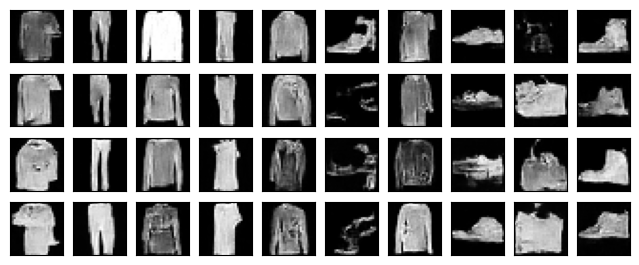

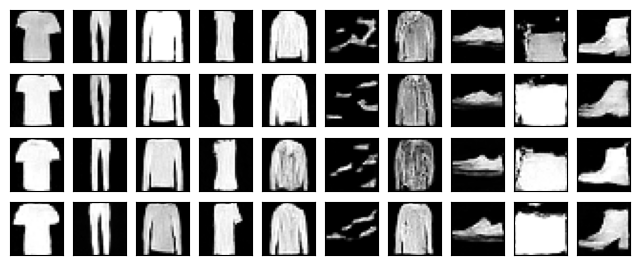

In [9]:
print('first grid: guidance scale 1; second grid: guidance scale 4; '
      'columns are the ten classes')
for gamma in (1.0, 4.0):
    show(guided[gamma][:40], 4, 10)  # the first four samples of each class

Class agreement rises with the guidance scale and within-class distance
falls: stronger guidance produces samples that the classifier assigns to
the requested class more reliably and that resemble one another more. The
grids, which show the first four samples of each class, show the same
effect. At $\gamma = 1$ each column contains varied
instances of its class, some ambiguous; at $\gamma = 4$ the instances are
cleaner and more prototypical, and closer to one another. The cost is
visible too: at $\gamma = 4$ several samples saturate to white, and the
sandal column improves little. The trade-off is the one that
@Ho.Salimans.2022 report on ImageNet, where guidance improves
fidelity metrics at the cost of diversity, so the guidance scale is a
setting chosen for each application rather than a constant fixed by the
derivation.

### Classifier Guidance

Classifier-free guidance obtains the class direction from the diffusion
network itself. The older route, *classifier guidance*
[@Dhariwal.Nichol.2021], obtains it from a separate classifier and
asks nothing of the diffusion model beyond an unconditional prediction.
Written for the noise prediction, the Bayes-rule identity
the equation becomes

$$
\hat{\boldsymbol{\epsilon}}(\mathbf{x}_t, t, c)
= \boldsymbol{\epsilon}_{\boldsymbol{\theta}}(\mathbf{x}_t, t, \varnothing)
- s\, \sqrt{1 - \bar{\alpha}_t}\; \nabla_{\mathbf{x}_t} \log p_{\boldsymbol{\phi}}(c \mid \mathbf{x}_t, t),
$$

where $p_{\boldsymbol{\phi}}$ is a classifier of *noisy* images that takes
the step $t$ as an input, and the scale $s$ plays the role of $\gamma$:
$s = 1$ would sample from the Bayes-rule conditional if $p_{\boldsymbol{\phi}}$
were the exact class posterior of the noisy images, and $s > 1$ sharpens it.
The factor $\sqrt{1 - \bar{\alpha}_t}$ converts the score-space gradient
into the noise-prediction convention of the equation.
The classifier must be trained on noisy images because its gradient is
taken at $\mathbf{x}_t$, an image at noise level $t$; a classifier trained
only on clean images never saw such inputs, so its gradient there does not
estimate $\nabla_{\mathbf{x}_t} \log p_t(c \mid \mathbf{x}_t)$. The cell trains such a
classifier, the architecture of the classifier above with a second input
channel that carries the noise level $\sqrt{1 - \bar{\alpha}_t}$, on noisy
training images at random steps, and reports its accuracy on clean test
images and on test images at the middle of the schedule.

In [10]:
class NoisyClassifier(nn.Module):
    """A classifier of noisy images; the noise level enters as a second channel."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(2, 32, 3, 2, 1), nn.ReLU(),
                                 nn.Conv2d(32, 64, 3, 2, 1), nn.ReLU(), nn.Flatten(),
                                 nn.Linear(64 * 49, 128), nn.ReLU(), nn.Linear(128, 10))

    def forward(self, x, t):
        level = (1 - alpha_bar[t]).sqrt()[:, None, None, None].expand_as(x)
        return self.net(torch.cat([x, level], 1))

torch.manual_seed(3)
noisy_classifier = NoisyClassifier().to(device)
optimizer = torch.optim.Adam(noisy_classifier.parameters(), lr=1e-3)
for step in range(2000):
    idx = torch.randint(0, len(X), (128,), device=device)
    x0, y_batch = X[idx], Y[idx]
    t = torch.randint(0, T, (128,), device=device)
    a = alpha_bar[t][:, None, None, None]
    x_t = a.sqrt() * x0 + (1 - a).sqrt() * torch.randn_like(x0)
    loss = nn.functional.cross_entropy(noisy_classifier(x_t, t), y_batch)
    optimizer.zero_grad(), loss.backward(), optimizer.step()
with torch.no_grad():
    t_mid = torch.full((len(X_test),), T // 2, device=device)
    a = alpha_bar[t_mid][:, None, None, None]
    x_mid = a.sqrt() * X_test + (1 - a).sqrt() * torch.randn_like(X_test)
    t_clean = torch.zeros(len(X_test), dtype=torch.long, device=device)
    acc_clean = (noisy_classifier(X_test, t_clean).argmax(1) == Y_test).float().mean()
    acc_mid = (noisy_classifier(x_mid, t_mid).argmax(1) == Y_test).float().mean()
print(f'noisy classifier test accuracy: {acc_clean:.3f} at t = 0, '
      f'{acc_mid:.3f} at t = {T // 2}')

noisy classifier test accuracy: 0.853 at t = 0, 0.600 at t = 500


The sampler is the ancestral chain of `sample` with
the equation in place of the classifier-free
rule: at each step it takes the unconditional prediction of the same U-Net,
computes the gradient of the classifier's log-probability of the requested
class with respect to the current noisy image by automatic differentiation,
and combines the two. We run it for the same eighty requests at three
scales and score the samples with the clean classifier as before, so that
both rules are scored the same way.

scale  class agreement  within-class distance


  1.0            0.488                  18.54


  4.0            0.788                  16.12


 10.0            0.838                  15.19
first grid: scale 1; second grid: scale 10; columns are the ten classes


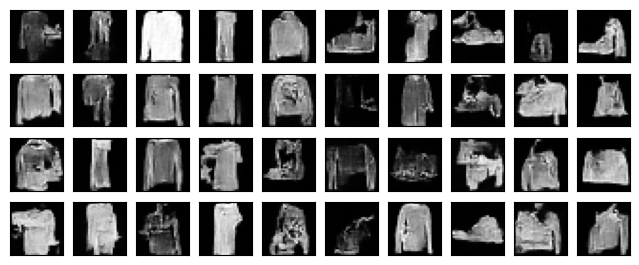

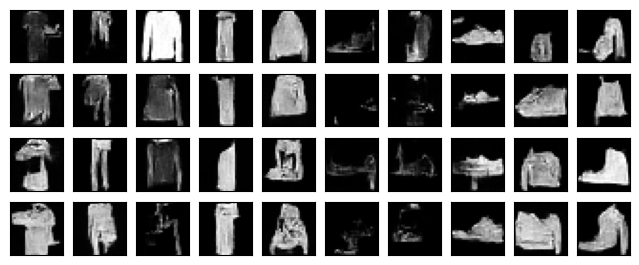

In [11]:
def classifier_gradient(classifier, x, t, y):
    """Gradient of log p(y | x_t) with respect to x_t for every image in the batch."""
    x = x.detach().requires_grad_(True)
    log_prob = torch.log_softmax(classifier(x, t), 1).gather(1, y[:, None]).sum()
    return torch.autograd.grad(log_prob, x)[0]

def sample_classifier_guided(net, classifier, y, scale, seed=0):
    """Ancestral sampling with classifier guidance of scale `scale`."""
    torch.manual_seed(seed)
    n, null = len(y), torch.full_like(y, NULL)
    x = torch.randn(n, 1, 28, 28, device=device)
    for t in reversed(range(T)):
        tt = torch.full((n,), t, device=device)
        with torch.no_grad():
            eps = net(x, tt, null)  # the unconditional prediction
        eps = eps - scale * (1 - alpha_bar[t]).sqrt() * classifier_gradient(
            classifier, x, tt, y)
        with torch.no_grad():
            mean = (x - beta[t] / (1 - alpha_bar[t]).sqrt() * eps) / alpha[t].sqrt()
            x = mean + (beta[t].sqrt() * torch.randn_like(x) if t > 0 else 0)
    return x

classifier_guided = {}
print(f'{"scale":>5} {"class agreement":>16} {"within-class distance":>22}')
for scale in (1.0, 4.0, 10.0):
    classifier_guided[scale] = sample_classifier_guided(
        ema, noisy_classifier, y, scale, seed=2).clamp(-1, 1)
    with torch.no_grad():
        agree = (classifier(classifier_guided[scale]).argmax(1) == y).float().mean()
    flat = classifier_guided[scale].flatten(1)
    dist = torch.stack([torch.pdist(flat[y == c]).mean() for c in range(10)]).mean()
    print(f'{scale:>5.1f} {agree:>16.3f} {dist:>22.2f}')
print('first grid: scale 1; second grid: scale 10; columns are the ten classes')
for scale in (1.0, 10.0):
    show(classifier_guided[scale][:40], 4, 10)

The noisy classifier is a few points less accurate than the clean one on
clean images and still right more often than not halfway through the
schedule. With the scale at one, which targets the Bayes-rule conditional,
classifier guidance steers only weakly: about half of the samples land in
the requested class, fewer than under classifier-free guidance at
$\gamma = 1$. @Dhariwal.Nichol.2021 report a similar weakness on
ImageNet: at scale one their samples did not match the requested classes on
inspection, although their guiding classifier gave those classes about fifty
percent probability; larger scales remedied this. Raising the scale raises agreement and lowers within-class
distance, as before; at a scale of ten the agreement matches that of
classifier-free guidance at $\gamma = 4$, while the within-class distance
stays larger. The grids temper this comparison: at scale ten, more samples
are malformed or faint than under classifier-free guidance at $\gamma = 4$.
Classifier guidance ascends the log-probability of a classifier with the
same architecture and training data as the one that scores the samples, so
it can raise agreement without producing a recognizable garment, and pixel
distance grows with such artifacts as well as with diversity;
@Ho.Salimans.2022 raise the same concern about classifier-based
metrics. The other cost is a second network, trained on noisy images, that
steers toward whatever it has learned, including its confusions between
similar garments. @Ho.Salimans.2022 introduced the classifier-free
rule to remove that network, and with it the need for a classifier of noisy
data.

## Outlook

The model trained here has the structure of the systems that generate
images from text, and the differences are matters of scale and of a few
later ideas, two of which the next sections develop. Sampling with a
thousand network evaluations is the main cost, and
that section shows that a trained noise predictor also
supports a deterministic sampler, which for a well-trained network needs
only a few dozen evaluations [@Song.Meng.Ermon.2020].
that section replaces the noise predictor by a
velocity field regressed on straight noise-to-data segments, the formulation
that
@Esser.Kulal.Blattmann.ea.2024 scale to large text-to-image models,
and shows how the two views are related. that section
then extends the construction to categorical data such as text.

Four further lines of work act on different parts of the model.

On the sampler, improved schedules and learned reverse variances
[@Nichol.Dhariwal.2021] and a careful redesign of the noise
parameterization and sampler [@Karras.Aittala.Aila.ea.2022] reduce
the step count further, and distillation trains a student to reproduce the
sampler's output in one to four evaluations
[@Salimans.Ho.2022; @Song.Dhariwal.Chen.ea.2023]; a later line of
distillation adds an adversarial loss to the student
[@Sauer.Lorenz.Blattmann.ea.2023], which is where adversarial
training re-enters (that section).

On the data space, latent
diffusion [@Rombach.Blattmann.Lorenz.ea.2022] runs the diffusion in
the latent space of an autoencoder, so that its U-Net, itself hundreds of
millions of parameters or more, operates on a compressed image, and the
decoder maps each generated latent back to an image in a single pass.
Sampling in the smaller space is much cheaper, but the images are limited
by what the autoencoder preserves: @Rombach.Blattmann.Lorenz.ea.2022
find that too strong a compression limits the achievable quality and too
weak a compression slows training. The model conditions on text through
cross-attention layers inside the U-Net that attend to the token embeddings
of a text encoder, a richer injection than the single vector added to the
time embedding here.

On the backbone, transformers replace the U-Net at the largest scales
[@Peebles.Xie.2023].

On the objective and the theory, the variational bound of
that section also makes diffusion models competitive
likelihood estimators when trained on it rather than on the simple loss
[@Kingma.Salimans.Poole.ea.2021], and the continuous-time view of
that section places the ladder, the
chain, and the samplers of this chapter in one framework: the ladder and
the chain discretize the variance-exploding and the variance-preserving
stochastic differential equations, the ancestral sampler discretizes the
reverse-time equation, and the deterministic sampler of
that section its probability-flow equation
[@song2021score]; @Lai.Song.Kim.ea.2025 develop that view in
full.

## Summary

A class-conditional diffusion model for images is the model of
that section with a U-Net as the noise predictor, a class
embedding added to the time embedding, and a null label that makes the same
network unconditional. Trained by the simple loss with label dropout, and
sampled with an exponential moving average of the weights, a network of
about 340 thousand parameters produces Fashion-MNIST samples, many of them
recognizable, after ten minutes of laptop training.

Classifier-free guidance combines the two predictions the network provides:
the guided noise prediction extrapolates from the unconditional prediction
through the conditional one by a scale $\gamma$. Increasing $\gamma$ raised
the fraction of samples that a classifier assigned to the requested class
and lowered the pixel distance between samples of the same class. These
are the proxies used here for fidelity and diversity, and the scale sets the
trade-off between them. Classifier guidance, which draws the class direction
from a separate classifier trained on noisy images, raised agreement and
lowered within-class distance in the same way on the same requests, at the
cost of that second network and with more malformed samples at the largest
scale. Fast samplers, latent-space diffusion, larger
backbones, and the continuous-time formulation build on the model of this
chapter rather than replacing it.

## Exercises

1. **Guidance in score space.** Starting from Bayes' rule at noise level
   $t$, derive the equation in two steps: express
   $\nabla \log p_t(c \mid \mathbf{x})$ through the conditional and
   unconditional scores, then convert scores to noise predictions using
   the equation. Show that $\gamma = 1$ recovers the
   conditional prediction exactly and that, for $\gamma \neq 1$, the guided
   field is the score of $p_t(\mathbf{x}) \, p_t(c \mid \mathbf{x})^\gamma$ up
   to normalization.
1. **The null label.** Suppose label dropout were omitted, so that the
   network never saw the null label during training. Which of the
   quantities in the equation would be untrained, and what would
   the sampler compute at $\gamma = 0$? Then explain why a dropout
   probability near one would also be harmful.
1. [code] **The moving average.** Sample forty-eight images with the raw
   weights `net` instead of `ema`, using the same seed, and compare the two
   grids. Then repeat the training with the decay held at $0.999$ from the
   first step, and explain what you observe in the averaged model's samples
   in terms of the warm-up.
1. [code] **Guidance scales.** Extend the guidance experiment to
   $\gamma \in \{0.5, 1, 2, 4, 8, 16\}$ and plot class agreement and
   within-class distance against $\gamma$. Describe what happens to the
   samples at the largest scales, and relate it to the caveat that the guided
   field is in general not the score of a noised data distribution.
1. [code] **Fewer sampling steps.** Modify `sample` to use every tenth step of
   the schedule, merging the skipped steps as in Exercise 6 of
   that section, and compare the samples and the classifier
   agreement with the full thousand-step sampler. How many steps can be
   removed before the samples degrade visibly?
1. [code] **Inpainting.** Take a test image, mask its lower half, and generate
   the missing half by ancestral sampling in which, after every reverse step,
   the known pixels are replaced by a noised copy of the original at the
   current step (drawn from the equation). Show the
   results for several images and explain why the replacement uses the
   noised original rather than the clean one.